# pyGAlib example: Identifying a 'rich-club' supramodule in (undirected) graphs
Author: **Gorka Zamora-López, Ph.D.**

<div align="left">
<img src="Images/Logo_CAS_ICS.png" align="left" width="254" alt="logo ICS">
</div>

<br>
<br>

---------------------

This notebook illustrates how to look for the presence (or the absence) of a rich-club hierarchical feature in undirected graphs. A network is said to have a rich-club when

1. the network containts highly connected nodes (hubs), and
2. the hubs are densely interconnected with each other.

Unfortunately, the rich-club is a qualitative property of networks and no direct quantitative estimation exist to determine whether a network contains a rich-club or not and, in affirmative case, which hubs exactly form the rich-club. These decisions are interpreted from another metric, the __*k*-density__, $\Phi(k)$, that evaluates the density of connections between all nodes with degree *k'* larger than a chosen *k*. 

For comparison, here we will also estimate the *k*-density of two types of surrogate networks, namely (a) *random graphs* of same size and density and (b) *rewired graphs* that conserve the degree distribution.
See also example script *RichClub_Undirected.py* in this folder.


## Import dependencies

The Notebook requires a __*Python*__ (>=3.6) installation together with __*NumPy*__ (>1.6) and __*pyGAlib*__ (>=2.0), and __*Matplotlib*__ for the visualizations. Please make sure these packages are installed in the same environment in which this notebook is running.


In [1]:
# 1) Python standard library imports

# Third-party imports
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Local libraries
import galib


## 1) Load the connectivity matrix of a graph
Choose one of the graphs ('Zachary', 'CatCortex' or 'Miserables') locally available in folder *.Data/* and print some basic information.

In [2]:
# Choose one the three networks 'Zachary', 'CatCortex' or 'Miserables'
netcase = 'Miserables'

# Define the local path to the datasets
dataroot = 'Data/'

if netcase == 'Zachary':
    net = np.loadtxt(dataroot + 'Zachary.txt', dtype=np.uint8)
elif netcase == 'Miserables':
    net = galib.tools.LoadFromPajek(dataroot + 'LesMiserables.net')
elif netcase == 'CatCortex':
    net = np.loadtxt(dataroot + 'Cat53_cortex_sym.txt').astype(np.uint8)

# Get some basic properties of the network
N = len(net)
L = int( 0.5 * net.astype(bool).sum() )
dens = galib.Density(net)

# Print some quick feedback
print( f"{netcase}\tNumber of nodes: {N}" )
print( f"\t\tNumber of edges: {L}\n\t\tDensity: {dens:1.3f}" )


Miserables	Number of nodes: 77
		Number of edges: 254
		Density: 0.087


Visualise the adjacency matrix and the degree distribution

Text(0, 0.5, 'Counts')

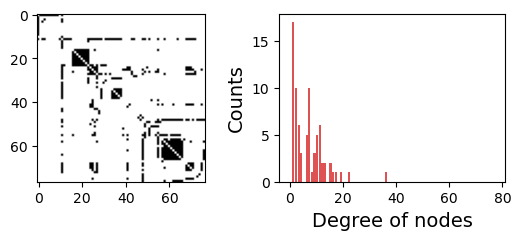

In [3]:
# Compute the degree of all nodes
deg = galib.Degree(net)

# Plot the degree distribution
plt.figure()
plt.subplot(2,2,1)
plt.imshow(net.astype(bool), cmap='gray_r')

plt.subplot(2,2,2)
plt.hist(deg, bins=N, range=[0,N], width=0.8, color='tab:red', alpha=0.8, align='mid');
plt.xlabel( "Degree of nodes" )
plt.ylabel( "Counts" )
#plt.tight_layout()

## 2) Compute k-density of the network and identify rich-club nodes (if any)

The evaluation of __*k*-density__ ( $\Phi(k)$ ) is an iterative process that evaluates the link density of the subgraph made of nodes with degree $k' \geq k$. Given $k_{max}$ is the largest degree in a graph, at each iteration for $k = 0, 1, 2, \ldots, k_{max}$, we do the following:

1. Compute the density $\phi(k)$ of the graph made of nodes with $k' \geq k$.
2. Remove from the network all nodes with degree $k' < k$. 


### 2.1 - Compute k-density of the empirical graph

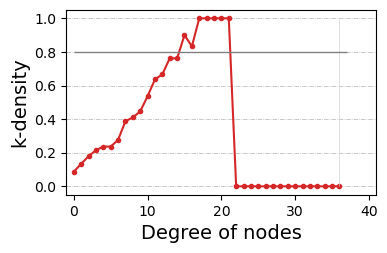

In [4]:
# Iteratively compute k-density for all degrees
kdens = galib.k_Density(net)

# Plot the k-density curve
kmax = deg.max()
klist = np.arange(0,kmax+1)

plt.figure(figsize=(4,2.4))
plt.plot(klist, kdens, '.-', color='tab:red')
plt.vlines(x=kmax, ymin=0,ymax=1,      color='lightgray', lw=0.5)
plt.hlines(y=0.8,  xmin=0,xmax=kmax+1, color='gray', lw=1)

plt.xlim(-1,kmax+5)
plt.xlabel('Degree of nodes')
plt.ylabel('k-density')
plt.grid(axis='y', ls='-.', lw=0.5)


The first point(s) of $\Phi(k)$ correspond to the density of the graph $\rho$, and thus by definition of k-density, $\Phi(0) = \rho$. Then, by iteratively removing the nodes with lowest degree (and conserving those nodes with larger degree) it is common that the remaining subnetwork to be denser than the original and therefore $\Phi(k)$ undergoes an initial growth in most cases. 

The key to identify whether a 'rich-club' is present is thus to interpret the shape of $\Phi(k)$ along all values of $k$, and what is the largest value it achieves. 

- If the network contains hubs, and these are densely interconnected, then $\Phi(k)$ is usually a monotonically growing curve, reaching high densities often above $0.8$.
- However, if the network contains no hubs, or it contains hubs but they are not well connected with each other, then $\Phi(k)$ typically shows an early decay after peaking at a value far from the highest densities.

Discrimination between these two behaviours can be somehow arbitrary and open to interpretation but in the three graphs employed in this example, for both Les Miserables and the cat cortex the presence of a rich-club is notable, as $\Phi(k)$ gradually increases to attain large values. For the Zachary karate club network, instead, $\Phi(k)$ soon decays indicating the absence of connections between the hubs of the two groups in the network.

### 2.2 - Identify the rich-club nodes

Next, we look for the set hubs whose interconnectivity is denser than a given threshold. We set initially this threshold to $\Phi(k) \geq 0.8$ but the user can try different ones. We will identify the smallest degree (`k_crit`) at which *k*-density overcomes the threshold, and will find the set of nodes (hubs) with $k \geq k_{crit}$ forming a subgraph with density of links larger than the threshold.


In [5]:
# Set a density threshold
phi_thres = 0.8

# Identify the degree k, at which k-density overcomes the given threshold
# And the set of nodes with degree larger than
try:
    k_crit = np.where(kdens >= phi_thres)[0][0]
    richclub = np.where(deg >= k_crit)[0]
except:
    k_crit = None
    richclub = []

print( "Degree 'k_crit' at which k-density overcomes threshold:", k_crit ) 
print( f"List of Rich-Club nodes (hubs) with internal density >= {phi_thres:1.3f}" )
print( richclub )



Degree 'k_crit' at which k-density overcomes threshold: 15
List of Rich-Club nodes (hubs) with internal density >= 0.800
[11 23 25 27 48 55 58]


## 3) Comparison to surrogate networks

Once we have evaluated whether a network may, or may not, have a rich-club it is often useful to inquire whether that observation is expected or not, under some assumptions. To do so, as with other network properties, we can compare the result to the outcome of random graphs that conserve some constraints. Here, we will evaluate the k-density out of two surrogate graph models:

1. Random graphs of same number of nodes $N$ and links $L$ as the original network.
2. Random graphs of same size $N$ and degree sequence as the original network.

k-density will be evaluated over an ensemble random graphs for each case. 
Define the number of surrogate graphs, for each case:

In [6]:
nrealiz = 100

### 3.1 - Random graphs of same size and density

In [7]:
# Initialise some helper arrays
deg_rand = np.zeros((nrealiz,N), np.uint64)
kdens_rand = np.zeros((nrealiz,N), np.float64)

# Compute k-density for various realizations
for re in range(nrealiz):
    # Generate the random graph of N nodes and L links
    randnet = galib.RandomGraph(N,L, directed=False)
    deg_rand[re] = galib.Degree(randnet)

    # Compute its k-density and save it
    _kdens = galib.k_Density(randnet, rctype='undirected')
    kdens_rand[re,:len(_kdens)] = _kdens

# Find the ensemble average k-densities, and the limiting cases
meanphi_rand = kdens_rand.mean(axis=0)
stdphi_rand  = kdens_rand.std(axis=0)
maxphi_rand = kdens_rand.max(axis=0)
minphi_rand = kdens_rand.min(axis=0)


Visualize the resultsVisualize the results

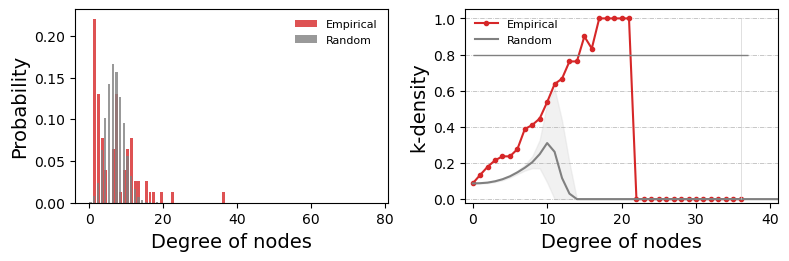

In [8]:
plt.figure(figsize=(8,4.8))

# 1) Plot the degree distributions
plt.subplot(2,2,1)
plt.hist(deg,              bins=N, range=[0,N], width=0.8, alpha=0.8, align='mid', density=True, color='tab:red', label='Empirical', zorder=0)
plt.hist(deg_rand.ravel(), bins=N, range=[0,N], width=0.6, alpha=0.8, align='mid', density=True, color='gray', label='Random', zorder=1 )
#plt.xlim(-1,kmax+5)
plt.xlabel('Degree of nodes')
plt.ylabel('Probability')
plt.legend(loc='upper right', fontsize=8)


# 2) Plot the k-densities
# Get the upper and lower bounds of the random graph ensemble
lowerphi_rand = meanphi_rand - stdphi_rand
lowerphi_rand = lowerphi_rand.clip(0,1)
upperphi_rand = meanphi_rand + stdphi_rand
upperphi_rand = upperphi_rand.clip(0,1)

nodelist = np.arange(N)

plt.subplot(2,2,2)
# The empirical graph
plt.plot(klist, kdens, '.-', color='tab:red', label='Empirical')
# The random graphs
plt.plot(nodelist, meanphi_rand, color='gray', label='Random')
plt.fill_between(nodelist, lowerphi_rand, upperphi_rand, color='lightgray', alpha=0.3, linewidth=1)
# Some decoration
plt.vlines(x=kmax, ymin=0,ymax=1,      color='lightgray', lw=0.5)
plt.hlines(y=0.8,  xmin=0,xmax=kmax+1, color='gray', lw=1)

plt.xlim(-1,kmax+5)
plt.ylim(-0.02,1.05)
plt.xlabel('Degree of nodes')
plt.ylabel('k-density')
plt.grid(axis='y', ls='-.', lw=0.5)
plt.legend(loc='upper left', fontsize=8)

plt.tight_layout()

Random graphs (gray data) tend to have a narrower degree distribution (a Poissonian distribution with peak at the average degree) than empirical graphs. They don't contain hubs and connection probability between nodes of largest degrees is the same as with any other node, therefore, they don't form (on average) denser subsets as other subsets chosen at random. As a result, the k-density of random graphs rapidly decays after $k$ is larger than the average degree. The shaded gray area represents the standard deviation of $\Phi_{rand}(k)$ across all realizations.

### 3.2 - Random graphs of same size and degree sequence

In [9]:
# Initialise some helper arrays
deg_rew = np.zeros((nrealiz,N), np.uint64)
kdens_rew = np.zeros((nrealiz,N), np.float64)

# Compute k-density for various realizations
for re in range(nrealiz):
    # Generate the random graph of N nodes and L links
    rewnet = galib.RewireNetwork(net, prewire=10, directed=False)
    deg_rew[re] = galib.Degree(rewnet)

    # Compute its k-density and save it
    _kdens = galib.k_Density(rewnet, rctype='undirected')
    kdens_rew[re,:len(_kdens)] = _kdens

# Find the ensemble average k-densities, and the limiting cases
meanphi_rew = kdens_rew.mean(axis=0)
stdphi_rew  = kdens_rew.std(axis=0)
maxphi_rew = kdens_rew.max(axis=0)
minphi_rew = kdens_rew.min(axis=0)


Visualize the resultsVisualize the results

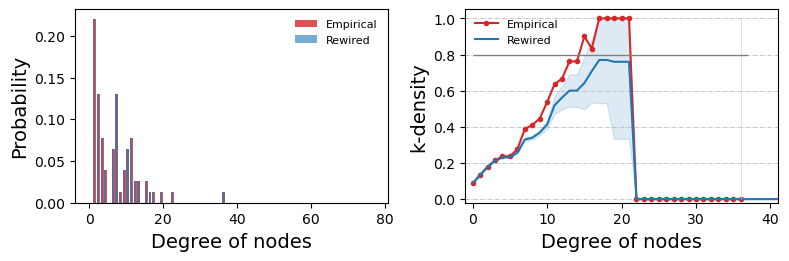

In [10]:
plt.figure(figsize=(8,4.8))

# 1) Plot the degree distributions
plt.subplot(2,2,1)
plt.hist(deg,             bins=N, range=[0,N], width=0.8, alpha=0.8, align='mid', density=True, color='tab:red', label='Empirical', zorder=0)
plt.hist(deg_rew.ravel(), bins=N, range=[0,N], width=0.6, alpha=0.6, align='mid', density=True, color='tab:blue', label='Rewired', zorder=1 )
#plt.xlim(-1,kmax+5)
plt.xlabel('Degree of nodes')
plt.ylabel('Probability')
plt.legend(loc='upper right', fontsize=8)


# 2) Plot the k-densities
# Get the upper and lower bounds of the rewired ensemble
lowerphi_rew = meanphi_rew - stdphi_rew
lowerphi_rew = lowerphi_rew.clip(0,1)
upperphi_rew = meanphi_rew + stdphi_rew
upperphi_rew = upperphi_rew.clip(0,1)

nodelist = np.arange(N)

plt.subplot(2,2,2)
# The empirical graph
plt.plot(klist, kdens, '.-', color='tab:red', label='Empirical')
# The random graphs
plt.plot(nodelist, meanphi_rew, color='tab:blue', label='Rewired')
plt.fill_between(nodelist, lowerphi_rew, upperphi_rew, color='tab:blue', alpha=0.15, linewidth=1)
# Some decoration
plt.vlines(x=kmax, ymin=0,ymax=1,      color='lightgray', lw=0.5)
plt.hlines(y=0.8,  xmin=0,xmax=kmax+1, color='gray', lw=1)

plt.xlim(-1,kmax+5)
plt.ylim(-0.02,1.05)
plt.xlabel('Degree of nodes')
plt.ylabel('k-density')
plt.grid(axis='y', ls='-.', lw=0.5)
plt.legend(loc='upper left', fontsize=8)

plt.tight_layout()

The degree distribution of the rewired graphs (blue data) is the same as that of the empirical one, since the randomization process conserves the degree of every node. Thus, they contain hubs if the original graph has them. The behaviour of k-density of the rewired networks $\Phi_{rew}(k)$ tends to follow rather close the one of the empirical graphs, as the surrogates have the same degree sequence, although its growth tends to lie below, notably at the end of the iterative process, for the subgraphs formed by the largest connected nodes. In a random configurations the probability of two nodes to connect is proportional to their degrees ($p(i,i) \propto k_i * k_j$) and thus the hubs have a larger random chance of connecting with each other. In empirical graphs with a rich-club, their connection probability (density) is usually even higher than this random chance.